# nb03 · 工况与动态负载（Experiment / Drive cycle）

本篇目标：

1. 用 `pybamm.Experiment` 描述 **CCCV 充电 + 恒流放电** 的多步循环协议。
2. 从 CSV 读入**电流时间序列（drive cycle）**，用 `pybamm.Interpolant` 构造动态输入电流，提取 SOC / 电压 / 电流。
3. 演示**功率驱动**（恒功率）负载——更贴近无人机 / EV 的真实工况。

> 约定：PyBaMM 中正电流为放电、负电流为充电。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
param = pybamm.ParameterValues("Chen2020")
nominal_cap = param["Nominal cell capacity [A.h]"]
print("PyBaMM 版本:", pybamm.__version__, "| 标称容量 [A.h]:", nominal_cap)

PyBaMM 版本: 26.6.1.1 | 标称容量 [A.h]: 5.0


## 1. CCCV 充电 + 恒流放电的多步循环

`Experiment` 用自然语言字符串描述每一步；`* N` 表示循环 N 次。这里做 2 个充放循环。

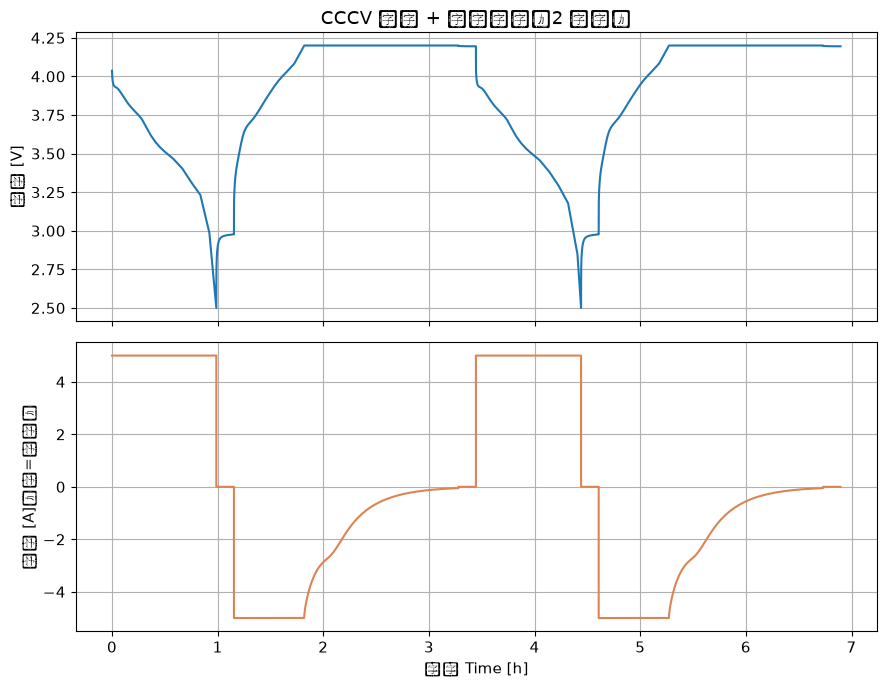

In [2]:
experiment = pybamm.Experiment(
    [
        (
            "Discharge at 1C until 2.5 V",
            "Rest for 10 minutes",
            "Charge at 1C until 4.2 V",
            "Hold at 4.2 V until 50 mA",
            "Rest for 10 minutes",
        )
    ]
    * 2
)

model = pybamm.lithium_ion.SPMe()
sim = pybamm.Simulation(model, parameter_values=param, experiment=experiment)
sol = sim.solve()

t_h = sol["Time [s]"].entries / 3600
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
ax1.plot(t_h, sol["Terminal voltage [V]"].entries)
ax1.set_ylabel("电压 [V]")
ax1.set_title("CCCV 充电 + 恒流放电（2 循环）")
ax2.plot(t_h, sol["Current [A]"].entries, color="#DD8452")
ax2.set_ylabel("电流 [A]（正=放电）")
ax2.set_xlabel("时间 Time [h]")
plt.tight_layout()
plt.show()

## 2. Drive cycle：从 CSV 读入动态电流

先生成一个合成 drive cycle（含加速/巡航/制动回充段）保存到 `data/`，再读回，
用 `pybamm.Interpolant(t, I, pybamm.t)` 作为 `Current function [A]` 输入模型。

In [3]:
# --- 生成合成 drive cycle 并保存 ---
t = np.arange(0, 1200 + 1, 1.0)  # 20 分钟，1 s 步长
I = (
    3.0
    + 2.5 * np.sin(2 * np.pi * t / 200.0)        # 周期性加减速
    + 1.0 * np.sin(2 * np.pi * t / 47.0)         # 高频扰动
)
brake = ((t % 300) >= 150) & ((t % 300) < 180)   # 每 5 分钟中段一次制动回充
I[brake] = -4.0                                   # 负电流 = 充电（回馈）
drive = pd.DataFrame({"time [s]": t, "current [A]": I})
csv_path = os.path.join(DATA_DIR, "drive_cycle.csv")
drive.to_csv(csv_path, index=False)
print("已保存:", csv_path, "| 行数:", len(drive))

# --- 读回并构造插值电流 ---
drive = pd.read_csv(csv_path)
t_data = drive["time [s]"].to_numpy()
i_data = drive["current [A]"].to_numpy()

param_dc = pybamm.ParameterValues("Chen2020")
param_dc["Current function [A]"] = pybamm.Interpolant(t_data, i_data, pybamm.t, name="drive")

# 初始 SOC 取 0.7，为制动回充留出电压上限余量（避免开局即触发上截止电压）
sim_dc = pybamm.Simulation(pybamm.lithium_ion.SPMe(), parameter_values=param_dc)
sol_dc = sim_dc.solve([t_data[0], t_data[-1]], initial_soc=0.7)

已保存: data/drive_cycle.csv | 行数: 1201


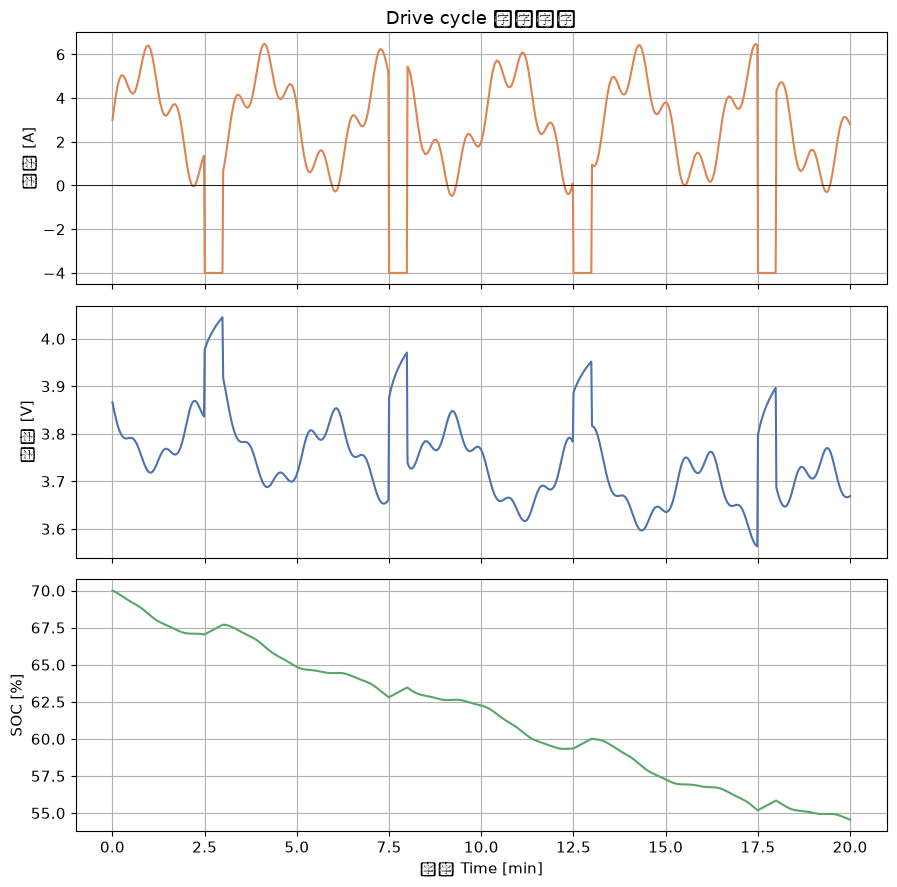

净放电安时: 0.773 A.h | SOC 变化: 0.773 A.h（应接近）


In [4]:
t_s = sol_dc["Time [s]"].entries
V = sol_dc["Terminal voltage [V]"].entries
I_out = sol_dc["Current [A]"].entries
# SOC 由已放出容量推算：SOC = SOC0 - 放出容量 / 标称容量
SOC0 = 0.7
soc = SOC0 - sol_dc["Discharge capacity [A.h]"].entries / nominal_cap

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].plot(t_s / 60, I_out, color="#DD8452"); axes[0].set_ylabel("电流 [A]")
axes[0].axhline(0, color="k", lw=0.6); axes[0].set_title("Drive cycle 动态响应")
axes[1].plot(t_s / 60, V, color="#4C72B0"); axes[1].set_ylabel("电压 [V]")
axes[2].plot(t_s / 60, soc * 100, color="#55A868"); axes[2].set_ylabel("SOC [%]")
axes[2].set_xlabel("时间 Time [min]")
plt.tight_layout(); plt.show()

# 校验：净安时积分（正放电使 SOC 下降）与 SOC 变化方向一致
net_Ah = np.trapezoid(I_out, t_s) / 3600
print(f"净放电安时: {net_Ah:.3f} A.h | SOC 变化: {(soc[0]-soc[-1])*nominal_cap:.3f} A.h（应接近）")

## 3. 功率驱动负载（恒功率放电）

无人机 / EV 的负载常以**功率**而非电流给定。`Experiment` 支持 `Discharge at P W` 形式。
恒功率放电时，随电压下降电流会自动上升。

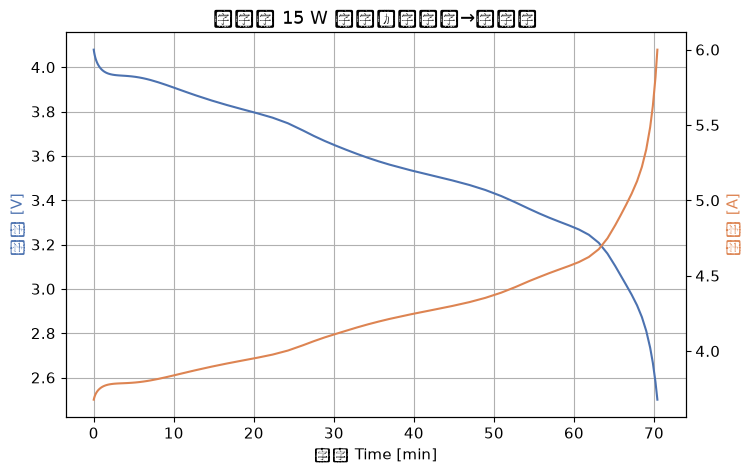

恒功率放电时长 [min]: 70.4


In [5]:
exp_power = pybamm.Experiment(["Discharge at 15 W until 2.5 V"])
sim_p = pybamm.Simulation(pybamm.lithium_ion.SPMe(), parameter_values=pybamm.ParameterValues("Chen2020"),
                          experiment=exp_power)
sol_p = sim_p.solve(initial_soc=1.0)

tp = sol_p["Time [s]"].entries / 60
fig, ax = plt.subplots()
ax.plot(tp, sol_p["Terminal voltage [V]"].entries, color="#4C72B0", label="电压 [V]")
ax.set_xlabel("时间 Time [min]"); ax.set_ylabel("电压 [V]", color="#4C72B0")
ax2 = ax.twinx()
ax2.plot(tp, sol_p["Current [A]"].entries, color="#DD8452", label="电流 [A]")
ax2.set_ylabel("电流 [A]", color="#DD8452"); ax2.grid(False)
ax.set_title("恒功率 15 W 放电：电压降→电流升")
plt.show()

print("恒功率放电时长 [min]:", round(float(sol_p["Time [s]"].entries[-1] / 60), 1))

## 小结

- `pybamm.Experiment([...]) * N` 可表达 CCCV、休息、循环等复杂测试协议。
- 任意电流 drive cycle 可通过 `pybamm.Interpolant(t, I, pybamm.t)` 设为 `Current function [A]` 输入。
- 恒功率负载用 `Discharge at P W` 描述，贴近真实电推进/EV 工况——这正是后续与螺旋桨电推进联动的接口（本期不整合）。
- 下一篇 `nb04` 进入**热模型**。